# ATIVIDADE (IR ALÉM) - Da Terra ao Código: Automatizando a Classificação de Grãos com Machine Learning

## Classificação de Variedades de Trigo com Machine Learning

**Contexto da atividade:** em cooperativas agrícolas de pequeno porte, a classificação dos grãos costuma ser realizada manualmente por especialistas. Esse processo pode ser demorado e sujeito a erros humanos. Com aprendizado de máquina, é possível automatizar parte dessa classificação, aumentando a eficiência, a padronização e a precisão do processo.

**Dataset utilizado:** Seeds Dataset, disponível no UCI Machine Learning Repository.  
**Metodologia usada:** CRISP-DM (*Cross Industry Standard Process for Data Mining*).  
**Objetivo:** analisar dados físicos de grãos de trigo, treinar modelos de classificação, comparar seus desempenhos, otimizar hiperparâmetros e interpretar os resultados obtidos.

As variedades classificadas neste notebook são:

- **Kama**
- **Rosa**
- **Canadian**

A classificação será feita com base em características físicas dos grãos, como área, perímetro, compacidade, dimensões do núcleo, assimetria e comprimento do sulco.


## 1. Entendimento do Negócio

Em cooperativas agrícolas de pequeno porte, a classificação manual de grãos pode consumir tempo, depender muito da experiência do especialista e gerar inconsistências. Um modelo de aprendizado de máquina pode apoiar esse processo ao classificar automaticamente as variedades de trigo a partir de medidas físicas.

Neste contexto, um bom modelo deve:

- apresentar boa capacidade de classificação nas três variedades;
- evitar favorecer apenas uma classe;
- ser simples o suficiente para ser explicado e comparado;
- permitir interpretação dos resultados para apoiar decisões no ambiente agrícola.

## 2. Entendimento dos Dados

O conjunto de dados possui **210 amostras** e **7 características numéricas** para cada grão. A última coluna representa a classe da variedade.

| Coluna | Descrição |
|---|---|
| `area` | área do grão |
| `perimetro` | Comprimento do contorno do grão |
| `compacidade` | Medida relacionada ao formato do grão |
| `comprimento_nucleo` | Comprimento do eixo principal do núcleo |
| `largura_nucleo` | Comprimento do eixo secundário do núcleo |
| `coeficiente_assimetria` | Medida da assimetria do grão |
| `comprimento_sulco_nucleo` | Comprimento do sulco central do grão |
| `classe` | Variedade do trigo: Kama, Rosa ou Canadian |

In [14]:
# Importação das bibliotecas principais
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Configurações visuais para deixar os gráficos mais legíveis
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Garante reprodutibilidade nos modelos que usam aleatoriedade
RANDOM_STATE = 42

### 2.1 Carregamento do Dataset

O arquivo original do UCI vem separado por espaços/tabulações e não possui cabeçalho. Por isso, os nomes das colunas serão definidos manualmente.

A célula abaixo procura o arquivo em dois locais possíveis:

- `seeds_dataset.txt`, caso o notebook esteja sendo executado dentro da pasta `seeds`;
- `seeds/seeds_dataset.txt`, caso o notebook esteja sendo executado a partir da raiz do projeto.

In [ ]:
colunas = [
    'area',
    'perimetro',
    'compacidade',
    'comprimento_nucleo',
    'largura_nucleo',
    'coeficiente_assimetria',
    'comprimento_sulco_nucleo',
    'classe',
]

caminhos_possiveis = [
    Path('seeds_dataset.txt'),
    Path('Notebook/seeds_dataset.txt'),
]

caminho_dataset = next((caminho for caminho in caminhos_possiveis if caminho.exists()), None)

if caminho_dataset is None:
    raise FileNotFoundError('Arquivo seeds_dataset.txt não encontrado.')

# sep=r'\s+' permite ler arquivos separados por qualquer quantidade de espaços ou tabulações.
df = pd.read_csv(caminho_dataset, sep=r'\s+', header=None, names=colunas)

df.head()

,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coeficiente_assimetria,comprimento_sulco_nucleo,classe
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [16]:
# Dimensões do conjunto de dados: linhas e colunas
df.shape

(210, 8)

In [17]:
# Informações gerais sobre tipos de dados e presença de valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   area                      210 non-null    float64
 1   perimetro                 210 non-null    float64
 2   compacidade               210 non-null    float64
 3   comprimento_nucleo        210 non-null    float64
 4   largura_nucleo            210 non-null    float64
 5   coeficiente_assimetria    210 non-null    float64
 6   comprimento_sulco_nucleo  210 non-null    float64
 7   classe                    210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


### 2.2 Dicionário das Classes

No arquivo original, a classe aparece como número. Para facilitar a interpretação dos resultados, vamos criar também uma coluna com o nome da variedade.

In [18]:
mapa_classes = {
    1: 'Kama',
    2: 'Rosa',
    3: 'Canadian',
}

df['variedade'] = df['classe'].map(mapa_classes)

df[['classe', 'variedade']].drop_duplicates().sort_values('classe')

,classe,variedade
0,1,Kama
70,2,Rosa
140,3,Canadian


In [19]:
# Verificação da quantidade de amostras por variedade
contagem_classes = df['variedade'].value_counts().sort_index()
contagem_classes

variedade
Canadian    70
Kama        70
Rosa        70
Name: count, dtype: int64

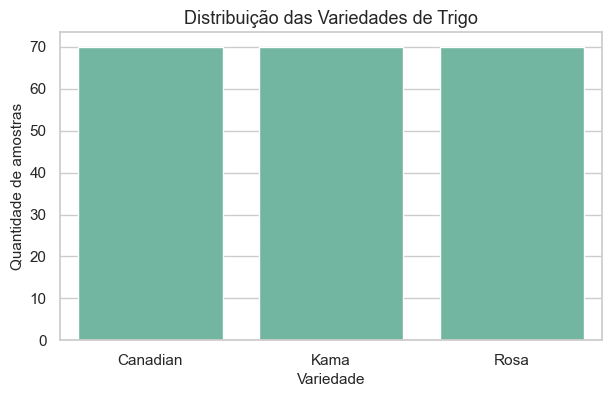

In [20]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='variedade', order=sorted(df['variedade'].unique()))
plt.title('Distribuição das Variedades de Trigo')
plt.xlabel('Variedade')
plt.ylabel('Quantidade de amostras')
plt.show()

**Observação:** o dataset é balanceado, pois possui a mesma quantidade de amostras para cada variedade. Isso é positivo, porque reduz o risco de um modelo ter boa acurácia apenas por favorecer a classe majoritária.

## 3. Preparação e Análise Exploratória dos Dados

Nesta etapa, vamos analisar estatísticas descritivas, distribuições, possíveis valores ausentes, relações entre variáveis e necessidade de escalonamento.

### 3.1 Estatísticas Descritivas

A atividade pede média, mediana e desvio padrão para cada característica. Também vamos manter outras medidas úteis, como mínimo, máximo e quartis.

In [21]:
features = colunas[:-1]
target = 'classe'

estatisticas = df[features].agg(['mean', 'median', 'std', 'min', 'max']).T
estatisticas = estatisticas.rename(columns={
    'mean': 'media',
    'median': 'mediana',
    'std': 'desvio_padrao',
    'min': 'minimo',
    'max': 'maximo',
})

estatisticas

,media,mediana,desvio_padrao,minimo,maximo
area,14.847524,14.35500,2.909699,10.5900,21.1800
perimetro,14.559286,14.32000,1.305959,12.4100,17.2500
compacidade,0.870999,0.87345,0.023629,0.8081,0.9183
comprimento_nucleo,5.628533,5.52350,0.443063,4.8990,6.6750
largura_nucleo,3.258605,3.23700,0.377714,2.6300,4.0330
coeficiente_assimetria,3.700201,3.59900,1.503557,0.7651,8.4560
comprimento_sulco_nucleo,5.408071,5.22300,0.491480,4.5190,6.5500


In [22]:
# Estatísticas descritivas completas, incluindo quartis
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
area,210.0,14.847524,2.909699,10.5900,12.27000,14.35500,17.305000,21.1800
perimetro,210.0,14.559286,1.305959,12.4100,13.45000,14.32000,15.715000,17.2500
compacidade,210.0,0.870999,0.023629,0.8081,0.85690,0.87345,0.887775,0.9183
comprimento_nucleo,210.0,5.628533,0.443063,4.8990,5.26225,5.52350,5.979750,6.6750
largura_nucleo,210.0,3.258605,0.377714,2.6300,2.94400,3.23700,3.561750,4.0330
coeficiente_assimetria,210.0,3.700201,1.503557,0.7651,2.56150,3.59900,4.768750,8.4560
comprimento_sulco_nucleo,210.0,5.408071,0.491480,4.5190,5.04500,5.22300,5.877000,6.5500


### 3.2 Valores Ausentes

Antes de treinar modelos, precisamos verificar se existem campos vazios. Valores ausentes podem prejudicar algoritmos que esperam entradas numéricas completas.

In [23]:
valores_ausentes = df.isna().sum().to_frame(name='quantidade_ausente')
valores_ausentes['percentual_ausente'] = (valores_ausentes['quantidade_ausente'] / len(df)) * 100
valores_ausentes

,quantidade_ausente,percentual_ausente
area,0,0.0
perimetro,0,0.0
compacidade,0,0.0
comprimento_nucleo,0,0.0
largura_nucleo,0,0.0
coeficiente_assimetria,0,0.0
comprimento_sulco_nucleo,0,0.0
classe,0,0.0
variedade,0,0.0


Como o dataset não possui valores ausentes, não é necessário aplicar imputação. Se houvesse valores ausentes, uma estratégia possível seria preencher com mediana, principalmente por se tratar de variáveis numéricas.

### 3.3 Histogramas

Os histogramas ajudam a visualizar a distribuição de cada característica: concentração dos valores, assimetria e possíveis separações entre grupos.

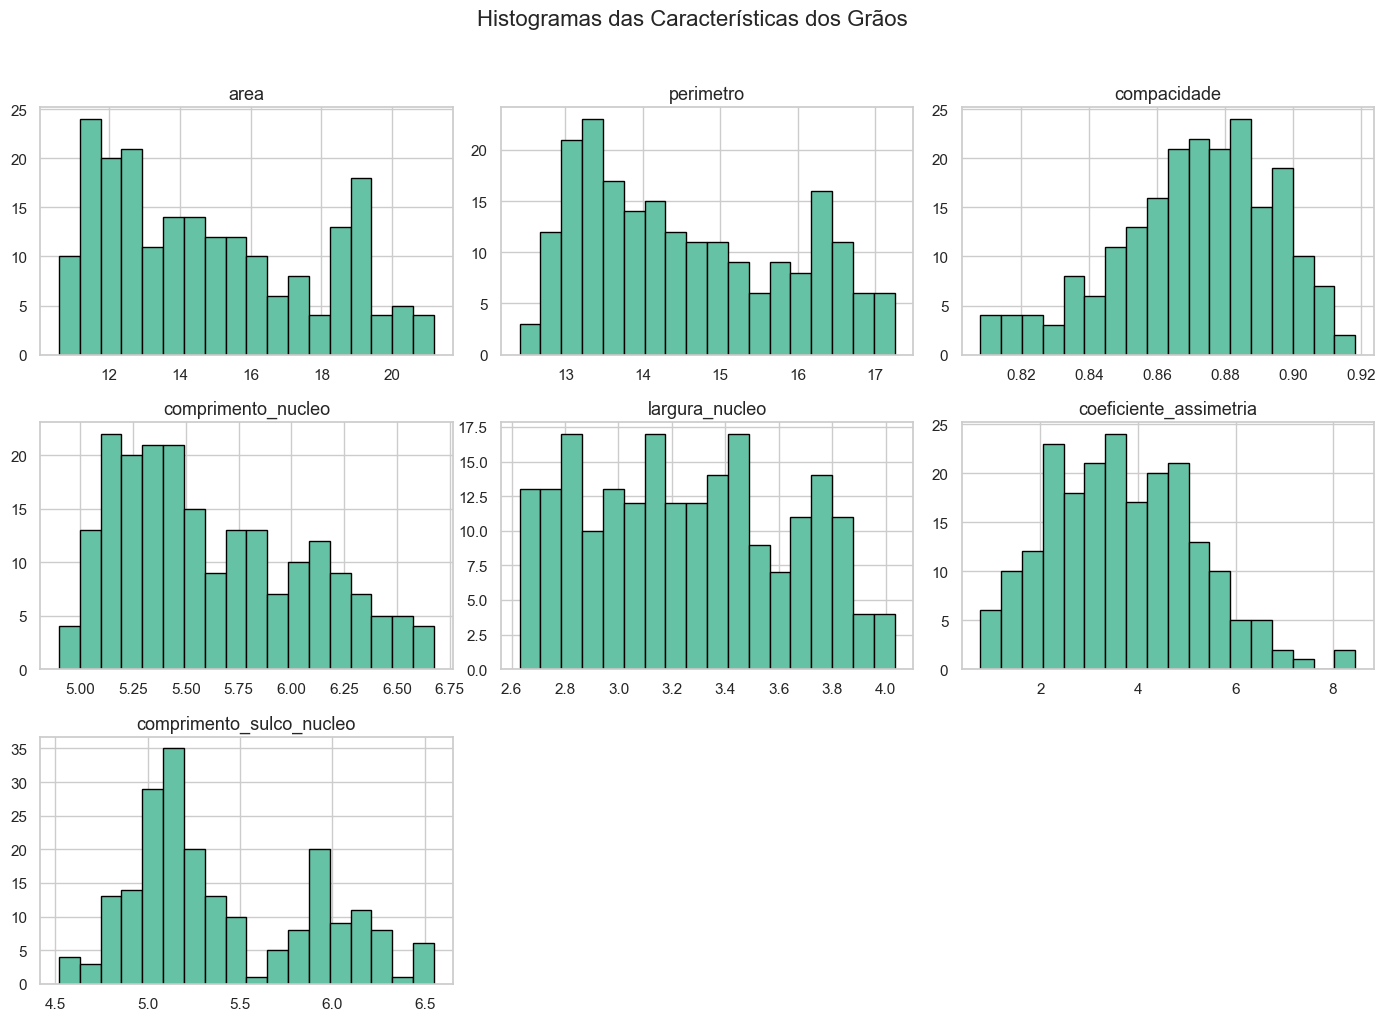

In [24]:
df[features].hist(bins=18, figsize=(14, 10), edgecolor='black')
plt.suptitle('Histogramas das Características dos Grãos', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### 3.4 Boxplots

Os boxplots permitem comparar escalas, dispersão e possíveis valores extremos. Aqui usamos um gráfico por característica para evitar distorções causadas por escalas diferentes.

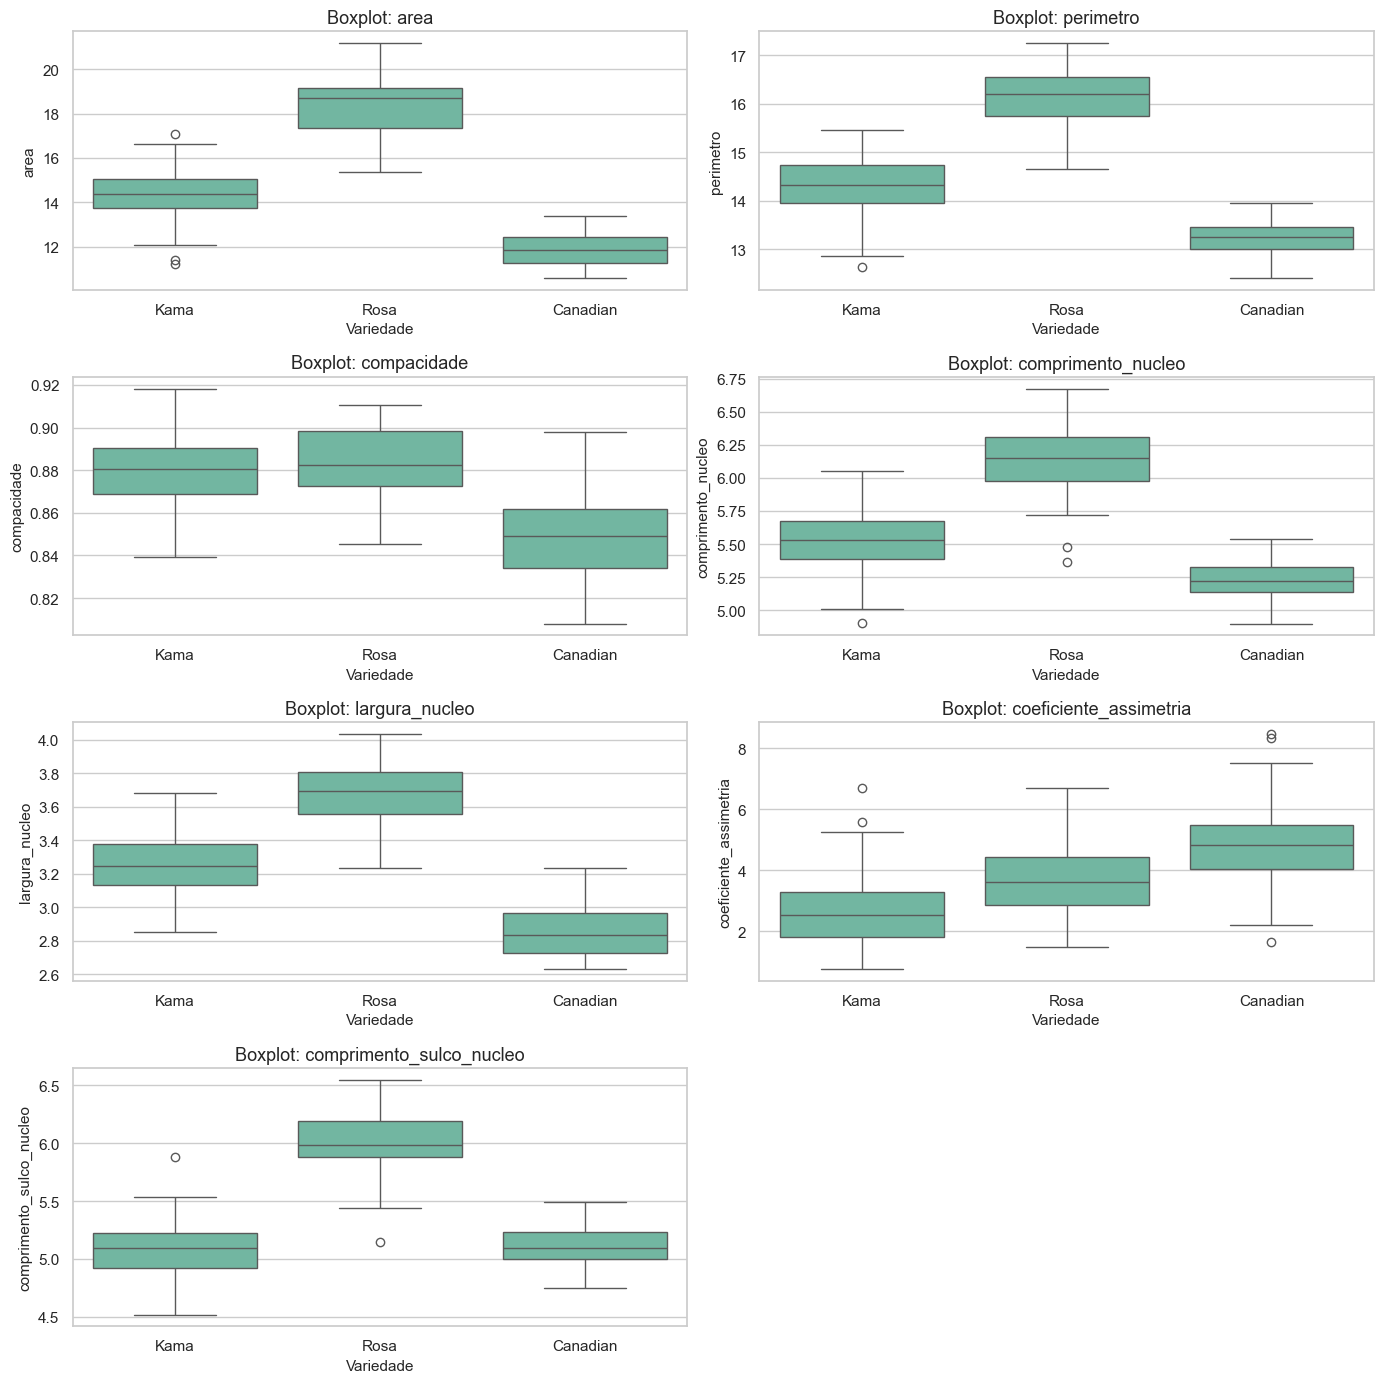

In [25]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for i, coluna in enumerate(features):
    sns.boxplot(data=df, x='variedade', y=coluna, ax=axes[i])
    axes[i].set_title(f'Boxplot: {coluna}')
    axes[i].set_xlabel('Variedade')
    axes[i].set_ylabel(coluna)

# Remove o eixo extra, pois temos 7 características e uma grade com 8 espaços.
axes[-1].axis('off')
plt.tight_layout()
plt.show()

### 3.5 Gráficos de Dispersão

Os gráficos de dispersão ajudam a identificar relações entre pares de variáveis e possíveis separações entre as variedades.

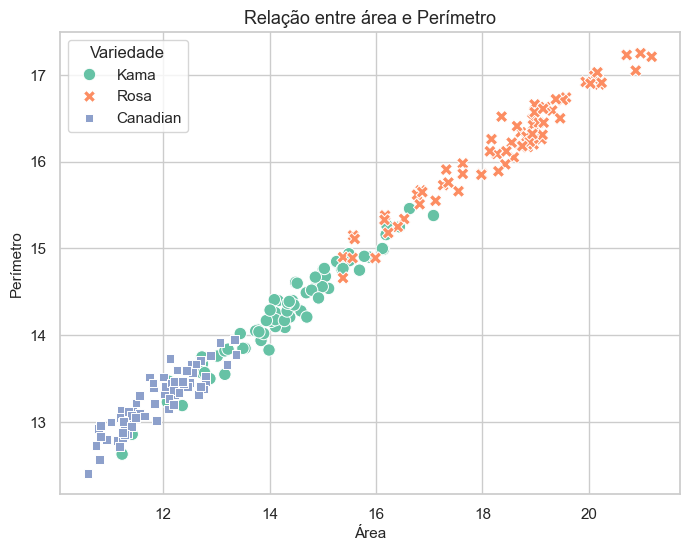

In [26]:
# Relação entre área e perímetro, duas medidas fortemente ligadas ao tamanho do grão.
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='area',
    y='perimetro',
    hue='variedade',
    style='variedade',
    s=80,
)
plt.title('Relação entre área e Perímetro')
plt.xlabel('Área')
plt.ylabel('Perímetro')
plt.legend(title='Variedade')
plt.show()

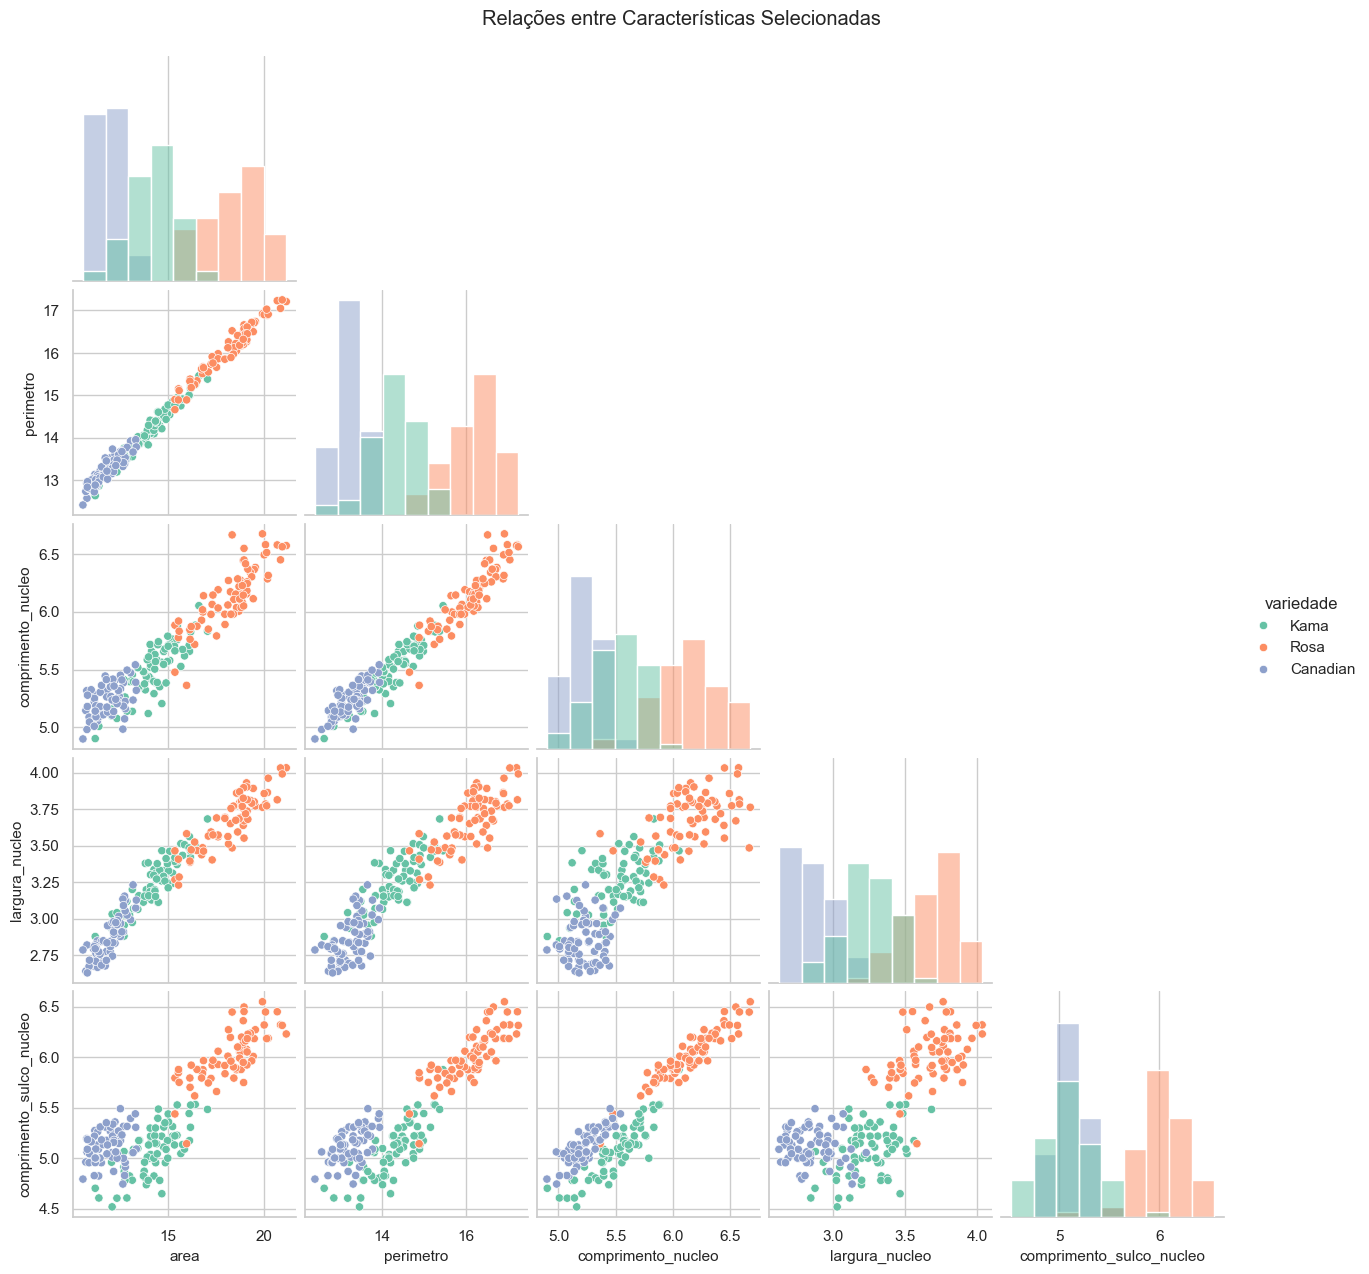

In [27]:
# Pairplot com algumas variáveis importantes para observar separação visual entre as classes.
variaveis_pairplot = [
    'area',
    'perimetro',
    'comprimento_nucleo',
    'largura_nucleo',
    'comprimento_sulco_nucleo',
    'variedade',
]

sns.pairplot(df[variaveis_pairplot], hue='variedade', corner=True, diag_kind='hist')
plt.suptitle('Relações entre Características Selecionadas', y=1.02)
plt.show()

### 3.6 Correlação entre Características

A matriz de correlação mostra o quanto duas variáveis numéricas se movem juntas. Valores próximos de 1 indicam correlação positiva forte; valores próximos de -1 indicam correlação negativa forte.

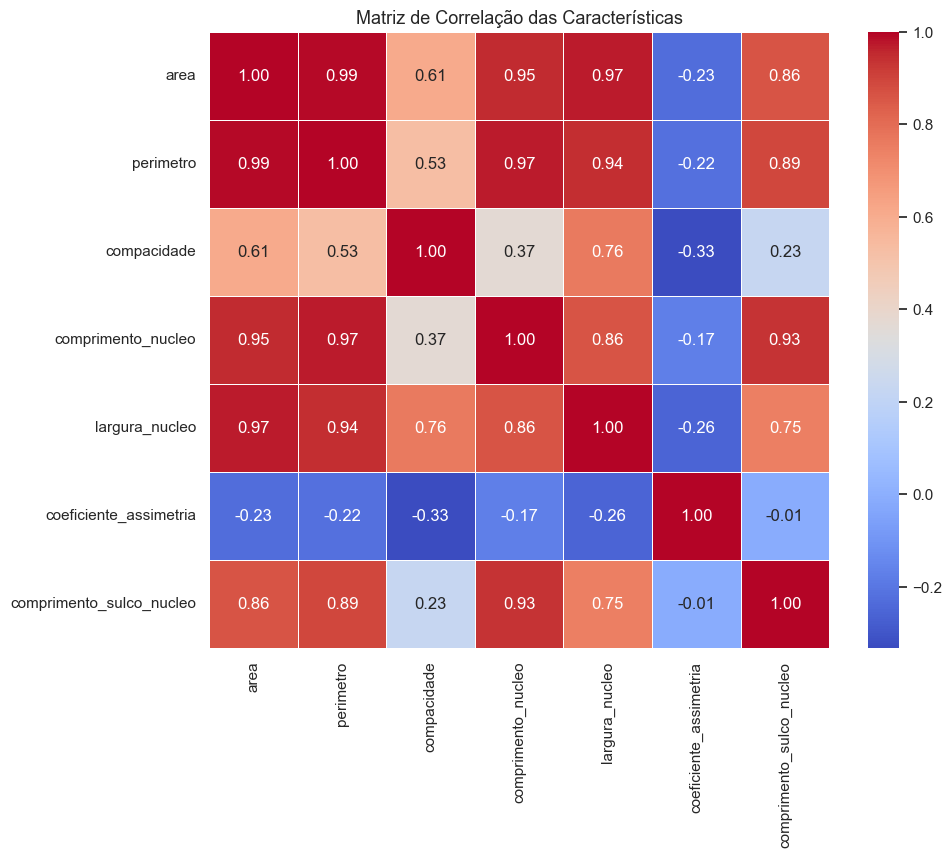

In [28]:
correlacao = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação das Características')
plt.show()

### 3.7 Necessidade de Escalonamento

Algoritmos baseados em distância ou margem, como **KNN**, **SVM** e **Regressão Logística**, são sensíveis é escala das variáveis. Como as características possuem unidades e amplitudes diferentes, será usada **padronização** com `StandardScaler` nesses modelos.

A padronização transforma cada variável para média aproximadamente 0 e desvio padrão aproximadamente 1. Isso evita que características com valores maiores dominem o treinamento.

Para **Random Forest** e **Naive Bayes**, o escalonamento não é tão necessário, mas o uso de `Pipeline` ajuda a manter o fluxo organizado.

In [29]:
# Separação entre variáveis explicativas (X) e variável alvo (y)
X = df[features]
y = df[target]

# Divisão estratificada mantém a proporção das classes no treino e no teste.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Tamanho do treino: {X_train.shape[0]} amostras')
print(f'Tamanho do teste: {X_test.shape[0]} amostras')
print('\nDistribuição das classes no treino:')
print(y_train.map(mapa_classes).value_counts().sort_index())
print('\nDistribuição das classes no teste:')
print(y_test.map(mapa_classes).value_counts().sort_index())

Tamanho do treino: 147 amostras
Tamanho do teste: 63 amostras

Distribuição das classes no treino:
classe
Canadian    49
Kama        49
Rosa        49
Name: count, dtype: int64

Distribuição das classes no teste:
classe
Canadian    21
Kama        21
Rosa        21
Name: count, dtype: int64


## 4. Modelagem: Implementação e Comparação dos Algoritmos

Serão testados cinco algoritmos de classificação:

- **K-Nearest Neighbors (KNN)**
- **Support Vector Machine (SVM)**
- **Random Forest**
- **Naive Bayes Gaussiano**
- **Regressão Logística**

A avaliação será feita no conjunto de teste usando acurácia, precisão, recall, F1-score e matriz de confusão.

In [30]:
modelos_base = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier()),
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=RANDOM_STATE)),
    ]),
    'Random Forest': Pipeline([
        ('model', RandomForestClassifier(random_state=RANDOM_STATE)),
    ]),
    'Naive Bayes': Pipeline([
        ('model', GaussianNB()),
    ]),
    'Regressão Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
}

In [31]:
def avaliar_modelo(nome, modelo, X_teste, y_teste):
    """Calcula métricas principais para um modelo de classificação."""
    y_pred = modelo.predict(X_teste)
    return {
        'modelo': nome,
        'acuracia': accuracy_score(y_teste, y_pred),
        'precisao_macro': precision_score(y_teste, y_pred, average='macro'),
        'recall_macro': recall_score(y_teste, y_pred, average='macro'),
        'f1_macro': f1_score(y_teste, y_pred, average='macro'),
    }

resultados_base = []
modelos_treinados_base = {}

for nome, modelo in modelos_base.items():
    modelo.fit(X_train, y_train)
    modelos_treinados_base[nome] = modelo
    resultados_base.append(avaliar_modelo(nome, modelo, X_test, y_test))

resultados_base_df = pd.DataFrame(resultados_base).sort_values('f1_macro', ascending=False)
resultados_base_df

,modelo,acuracia,precisao_macro,recall_macro,f1_macro
2,Random Forest,0.920635,0.923942,0.920635,0.919170
0,KNN,0.873016,0.872144,0.873016,0.871284
1,SVM,0.873016,0.872144,0.873016,0.871284
4,Regressão Logística,0.857143,0.857143,0.857143,0.854294
3,Naive Bayes,0.825397,0.833928,0.825397,0.825060


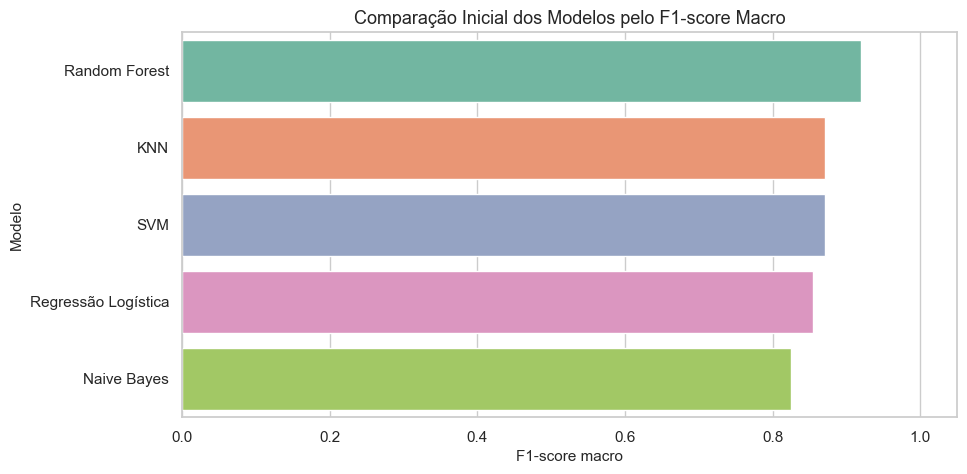

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(data=resultados_base_df, x='f1_macro', y='modelo', hue='modelo', dodge=False, legend=False)
plt.title('Comparação Inicial dos Modelos pelo F1-score Macro')
plt.xlabel('F1-score macro')
plt.ylabel('Modelo')
plt.xlim(0, 1.05)
plt.show()

### 4.1 Relatórios de Classificação dos Modelos Base

O relatório de classificação mostra precisão, recall e F1-score por classe. Isso é importante porque um modelo pode ter boa acurácia geral, mas desempenho ruim em uma variedade específica.

In [33]:
nomes_classes = [mapa_classes[i] for i in sorted(mapa_classes)]

for nome, modelo in modelos_treinados_base.items():
    print('=' * 80)
    print(f'Modelo: {nome}')
    print('=' * 80)
    y_pred = modelo.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=nomes_classes))

Modelo: KNN
              precision    recall  f1-score   support

        Kama       0.84      0.76      0.80        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63

Modelo: SVM
              precision    recall  f1-score   support

        Kama       0.84      0.76      0.80        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63

Modelo: Random Forest
              precision    recall  f1-score   support

        Kama       0.94      0.81      0.87        21
        Rosa       0.95      0.95      0.95        21
    Canadian       0.88      

### 4.2 Matrizes de Confusão dos Modelos Base

A matriz de confusão permite identificar quais variedades estão sendo confundidas entre si.

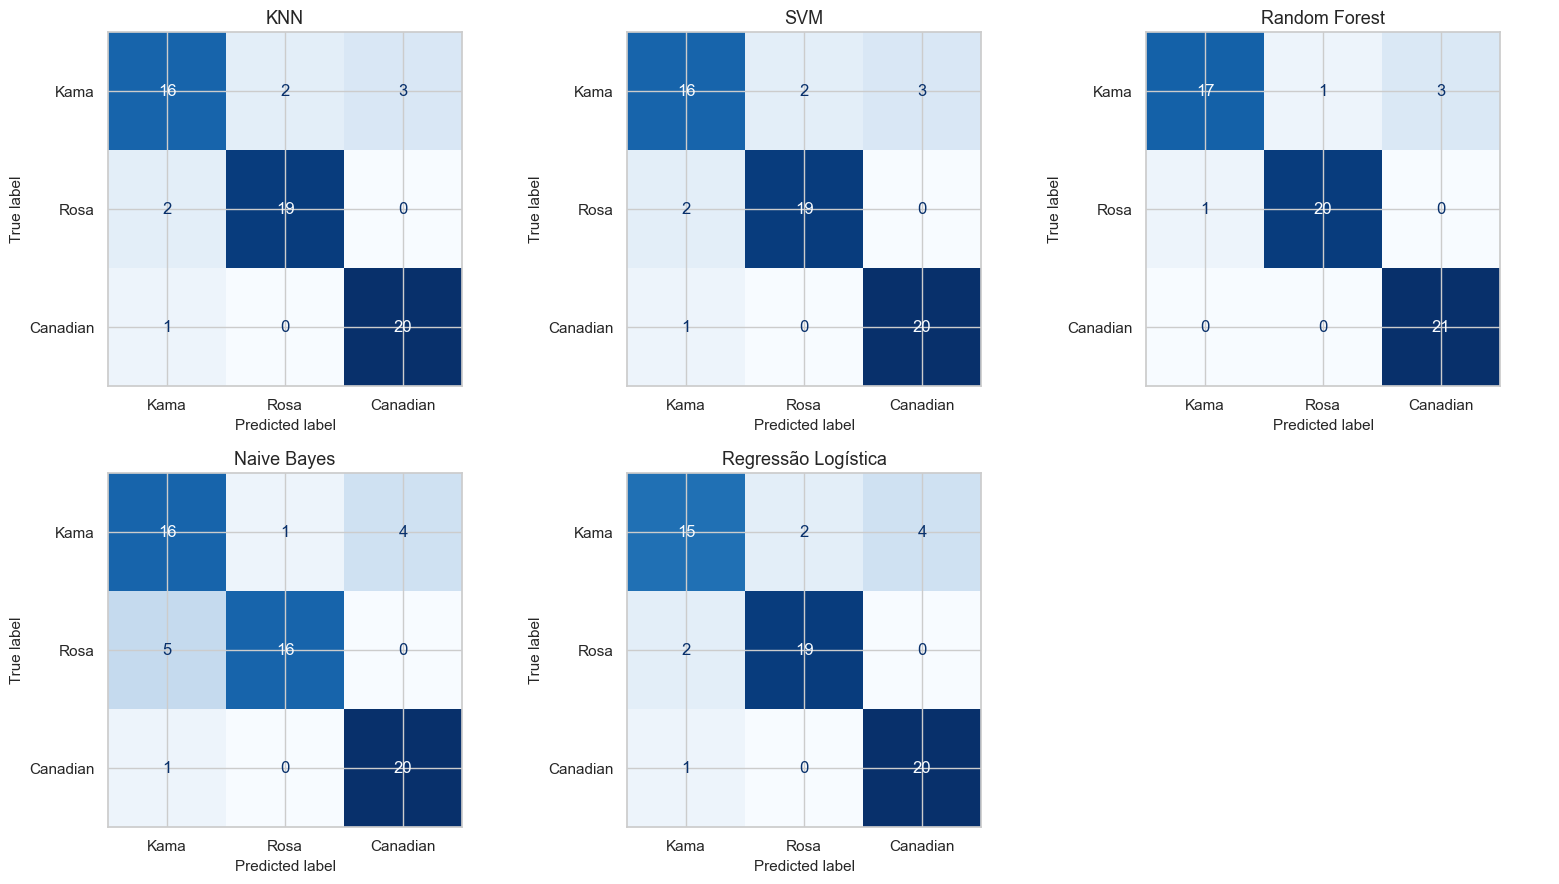

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (nome, modelo) in enumerate(modelos_treinados_base.items()):
    y_pred = modelo.predict(X_test)
    matriz = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=nomes_classes)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(nome)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 5. Otimização dos Modelos

Agora vamos usar **Grid Search** com validação cruzada para buscar melhores hiperparâmetros. A métrica usada na busca será `f1_macro`, pois ela considera o equilíbrio de desempenho entre as três classes.

Mesmo que os modelos base já tenham bom desempenho, a otimização é importante para verificar se combinações melhores de parâmetros aumentam a capacidade de generalização.

In [35]:
parametros_grid = {
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9, 11],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan'],
    },
    'SVM': {
        'model__C': [0.1, 1, 10, 100],
        'model__kernel': ['linear', 'rbf'],
        'model__gamma': ['scale', 'auto'],
    },
    'Random Forest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 3, 5, 10],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
    },
    'Naive Bayes': {
        'model__var_smoothing': np.logspace(-12, -7, 6),
    },
    'Regressão Logística': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['lbfgs'],
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
resultados_otimizados = []
melhores_modelos = {}
melhores_parametros = {}

for nome, modelo in modelos_base.items():
    print(f'Otimizando: {nome}')
    busca = GridSearchCV(
        estimator=modelo,
        param_grid=parametros_grid[nome],
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
    )
    busca.fit(X_train, y_train)

    melhores_modelos[nome] = busca.best_estimator_
    melhores_parametros[nome] = busca.best_params_
    resultados_otimizados.append(avaliar_modelo(nome, busca.best_estimator_, X_test, y_test))

resultados_otimizados_df = pd.DataFrame(resultados_otimizados).sort_values('f1_macro', ascending=False)
resultados_otimizados_df

Otimizando: KNN
Otimizando: SVM
Otimizando: Random Forest
Otimizando: Naive Bayes
Otimizando: Regressão Logística


,modelo,acuracia,precisao_macro,recall_macro,f1_macro
2,Random Forest,0.904762,0.911186,0.904762,0.902510
4,Regressão Logística,0.888889,0.889855,0.888889,0.888396
0,KNN,0.888889,0.887951,0.888889,0.888088
1,SVM,0.857143,0.855512,0.857143,0.854014
3,Naive Bayes,0.825397,0.833928,0.825397,0.825060


In [37]:
# Melhores hiperparâmetros encontrados para cada modelo
for nome, parametros in melhores_parametros.items():
    print(f'{nome}:')
    print(parametros)
    print()

KNN:
{'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'uniform'}

SVM:
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Random Forest:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Naive Bayes:
{'model__var_smoothing': np.float64(1e-12)}

Regressão Logística:
{'model__C': 10, 'model__solver': 'lbfgs'}



### 5.1 Comparação Antes e Depois da Otimização

A tabela abaixo compara o desempenho dos modelos base com os modelos otimizados. A coluna `melhoria_f1_macro` mostra a diferença obtida após a busca por hiperparâmetros.

In [38]:
comparacao = resultados_base_df.merge(
    resultados_otimizados_df,
    on='modelo',
    suffixes=('_base', '_otimizado'),
)

comparacao['melhoria_f1_macro'] = comparacao['f1_macro_otimizado'] - comparacao['f1_macro_base']
comparacao = comparacao.sort_values('f1_macro_otimizado', ascending=False)
comparacao

,modelo,acuracia_base,precisao_macro_base,recall_macro_base,f1_macro_base,acuracia_otimizado,precisao_macro_otimizado,recall_macro_otimizado,f1_macro_otimizado,melhoria_f1_macro
0,Random Forest,0.920635,0.923942,0.920635,0.919170,0.904762,0.911186,0.904762,0.902510,-0.016660
3,Regressão Logística,0.857143,0.857143,0.857143,0.854294,0.888889,0.889855,0.888889,0.888396,0.034102
1,KNN,0.873016,0.872144,0.873016,0.871284,0.888889,0.887951,0.888889,0.888088,0.016803
2,SVM,0.873016,0.872144,0.873016,0.871284,0.857143,0.855512,0.857143,0.854014,-0.017270
4,Naive Bayes,0.825397,0.833928,0.825397,0.825060,0.825397,0.833928,0.825397,0.825060,0.000000


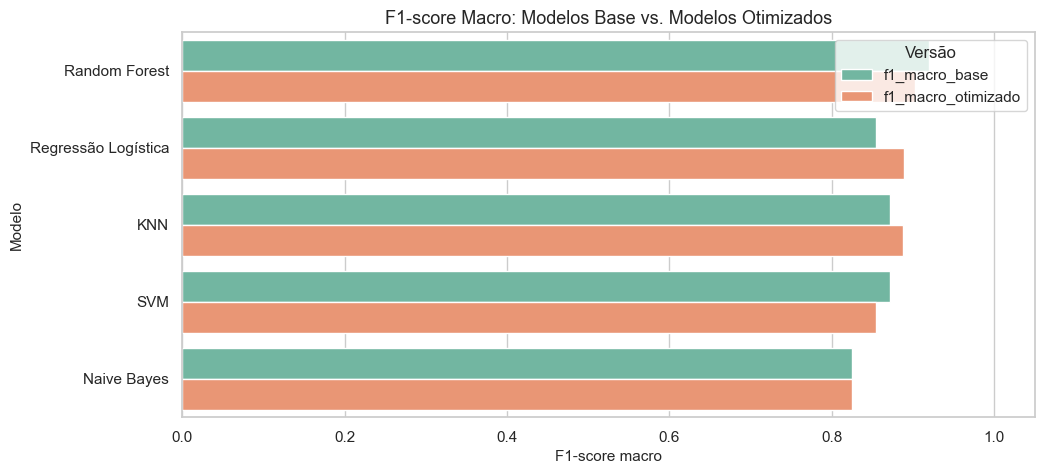

In [39]:
comparacao_plot = comparacao.melt(
    id_vars='modelo',
    value_vars=['f1_macro_base', 'f1_macro_otimizado'],
    var_name='versao',
    value_name='f1_macro',
)

plt.figure(figsize=(11, 5))
sns.barplot(data=comparacao_plot, x='f1_macro', y='modelo', hue='versao')
plt.title('F1-score Macro: Modelos Base vs. Modelos Otimizados')
plt.xlabel('F1-score macro')
plt.ylabel('Modelo')
plt.xlim(0, 1.05)
plt.legend(title='Versão')
plt.show()

### 5.2 Matrizes de Confusão dos Modelos Otimizados

Depois da otimização, verificamos novamente as matrizes de confusão para observar se as confusões entre variedades diminuíram.

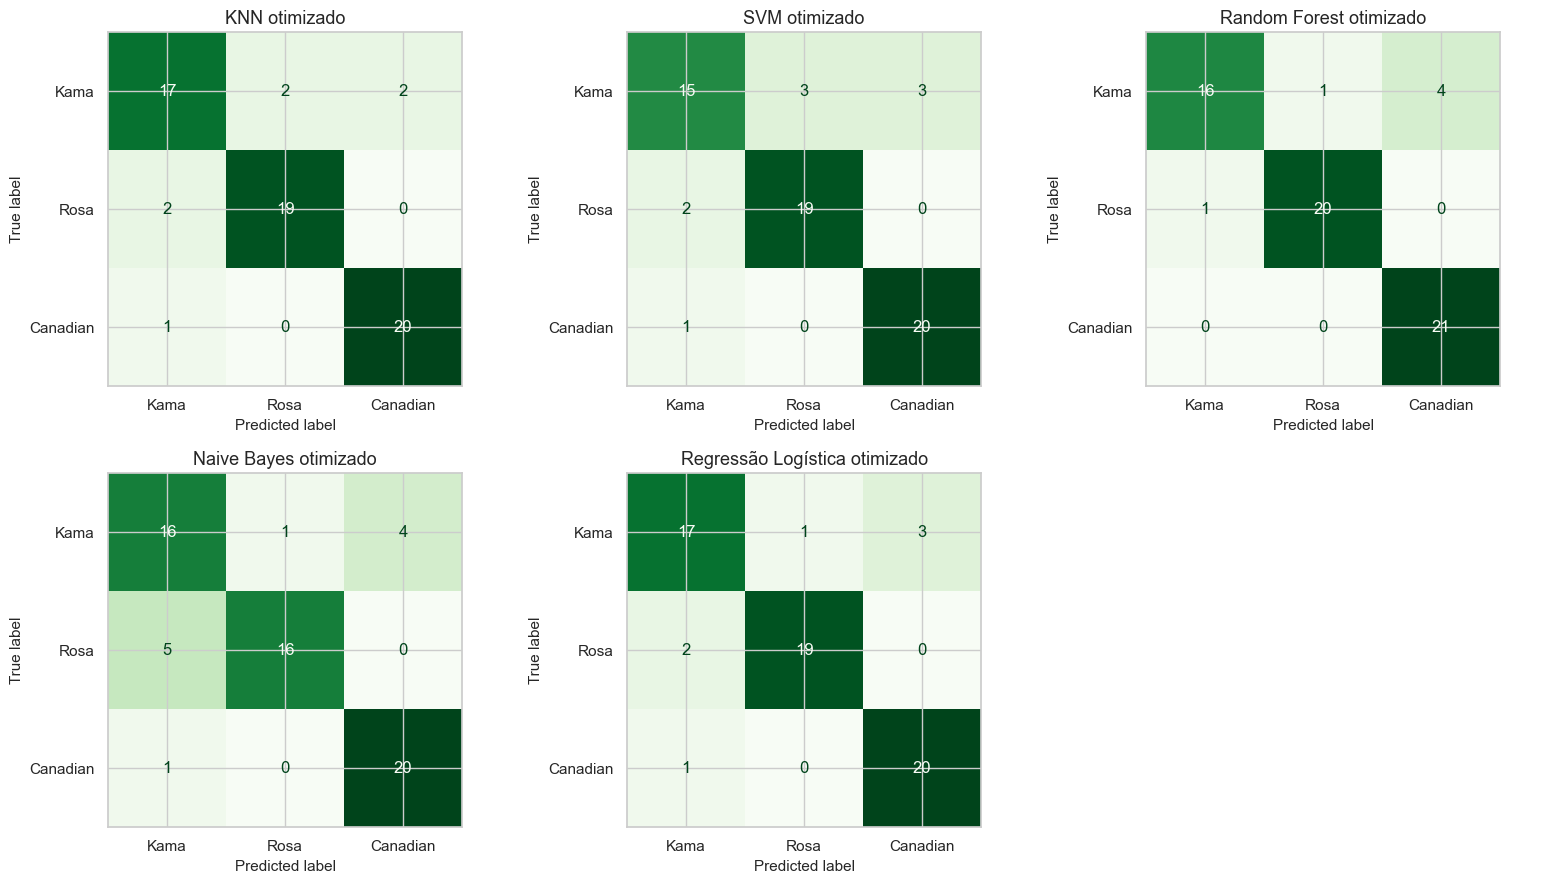

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (nome, modelo) in enumerate(melhores_modelos.items()):
    y_pred = modelo.predict(X_test)
    matriz = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=nomes_classes)
    disp.plot(ax=axes[i], cmap='Greens', colorbar=False)
    axes[i].set_title(f'{nome} otimizado')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

### 5.3 Melhor Modelo Final

Vamos selecionar o modelo com maior F1-score macro no conjunto de teste. Essa escolha é adequada porque as classes são balanceadas e queremos bom desempenho médio entre todas as variedades.

In [41]:
melhor_linha = resultados_otimizados_df.iloc[0]
melhor_nome = melhor_linha['modelo']
melhor_modelo = melhores_modelos[melhor_nome]

print(f'Melhor modelo: {melhor_nome}')
print(f"Acurácia: {melhor_linha['acuracia']:.4f}")
print(f"Precisão macro: {melhor_linha['precisao_macro']:.4f}")
print(f"Recall macro: {melhor_linha['recall_macro']:.4f}")
print(f"F1-score macro: {melhor_linha['f1_macro']:.4f}")
print('\nMelhores hiperparâmetros:')
print(melhores_parametros[melhor_nome])

Melhor modelo: Random Forest
Acurácia: 0.9048
Precisão macro: 0.9112
Recall macro: 0.9048
F1-score macro: 0.9025

Melhores hiperparâmetros:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [42]:
y_pred_melhor = melhor_modelo.predict(X_test)

print(classification_report(y_test, y_pred_melhor, target_names=nomes_classes))

              precision    recall  f1-score   support

        Kama       0.94      0.76      0.84        21
        Rosa       0.95      0.95      0.95        21
    Canadian       0.84      1.00      0.91        21

    accuracy                           0.90        63
   macro avg       0.91      0.90      0.90        63
weighted avg       0.91      0.90      0.90        63



## 6. Interpretação dos Resultados e Insights

Com base na análise exploratória e nos modelos treinados, podemos interpretar os principais pontos:

1. **O dataset é pequeno, mas bem organizado e balanceado.**  
   Existem 210 amostras distribuídas igualmente entre Kama, Rosa e Canadian, o que facilita uma avaliação mais justa dos modelos.

2. **Características relacionadas ao tamanho do grão são bastante informativas.**  
   área, perímetro, comprimento do núcleo e largura do núcleo apresentam relações visuais importantes e ajudam a separar parte das variedades.

3. **Algumas classes podem se sobrepor.**  
   Pelos gráficos de dispersão e matrizes de confusão, é possível observar que algumas variedades possuem medidas físicas parecidas. Isso explica eventuais erros de classificação.

4. **A padronização é importante para modelos sensíveis é escala.**  
   KNN, SVM e Regressão Logística dependem diretamente da escala das variáveis. Por isso, o uso de `StandardScaler` dentro de `Pipeline` torna o treinamento mais correto e evita vazamento de dados.

5. **A otimização por Grid Search permite refinar o desempenho.**  
   A busca por hiperparâmetros ajuda a encontrar combinações melhores para cada algoritmo. Mesmo quando a melhoria é pequena, ela torna a comparação mais confiável.

## 7. Conclusão

Este notebook aplicou a metodologia CRISP-DM para desenvolver uma solução de classificação automática de grãos de trigo. Foram realizadas as etapas de entendimento do problema, análise dos dados, pré-processamento, treinamento de modelos, avaliação, otimização e interpretação dos resultados.

No contexto de uma cooperativa agrícola, um modelo como este poderia servir como apoio é classificação de grãos, reduzindo o tempo de triagem e auxiliando especialistas humanos. Ainda assim, por se tratar de um dataset pequeno, recomenda-se validar o modelo com novas amostras reais antes de utilizá-lo em produção.

**Possíveis melhorias futuras:**

- coletar mais amostras de diferentes safras e regiões;
- testar outros algoritmos, como Gradient Boosting e XGBoost;
- avaliar técnicas de seleção de atributos;
- criar uma interface simples para entrada das medidas e retorno da variedade prevista.

## 8. Referência

Dataset utilizado:

- UCI Machine Learning Repository. **Seeds Dataset**. Disponível em: https://archive.ics.uci.edu/dataset/236/seeds